# ***TensorFlow NN***

# *Import Libraries*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import tensorflow as tf
from tensorflow.keras.models import Sequential # Linear stack of layers
from tensorflow.keras.layers import Dense # Creates a fully connected (dense) layer

# *Load & Prepare Dataset*

In [2]:
# Reading data and converting it to DataFrame
data = fetch_california_housing()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['Target'] = data.target

# Features and target
X = df.drop('Target', axis=1)
y = df['Target']

# Train-test split (67% training, 33% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fits on training data and scales it
X_test = scaler.transform(X_test) # Applies the same transformation to the test data

# *NN Building*

In [3]:
# Define the model
model = Sequential([
    # First layer with 5 neurons, ReLU activation, input layer with 8 neurons (features)
    Dense(5, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden layer 1
    # Second hidden layer with 3 neurons, ReLU activation
    Dense(3, activation='relu'),                                   # Hidden layer 2
    # final layer outputs a single number (regression target), no activation = linear
    Dense(1)                                                       # Output layer
    ])

# Compile the model
# 'adam': Adaptive Moment Estimation optimizer, fast and efficient,
# 'mse': Mean Squared Error (standard for regression),
# 'mae': Tracks Mean Absolute Error during training
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

# *Model Training*

In [4]:
# Training the model
# epochs=100: Full passes over the training data
# batch_size=32: Gradient updates every 32 samples
# validation_split=0.2: 20% of training data is used for validation
# verbose=1: Prints training progress
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Collect loss history
train_losses = history.history['loss']
val_losses = history.history['val_loss']

Epoch 1/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.8385 - mae: 2.0689 - val_loss: 4.4843 - val_mae: 1.7623
Epoch 2/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1589 - mae: 1.6677 - val_loss: 3.4864 - val_mae: 1.4636
Epoch 3/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.2398 - mae: 1.3871 - val_loss: 2.7647 - val_mae: 1.2329
Epoch 4/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.6478 - mae: 1.1932 - val_loss: 2.2449 - val_mae: 1.0766
Epoch 5/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1133 - mae: 1.0443 - val_loss: 1.8863 - val_mae: 0.9765
Epoch 6/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7757 - mae: 0.9507 - val_loss: 1.6525 - val_mae: 0.9190
Epoch 7/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5835 - mae: 0.9083 - val_loss: 1.5112 - val_mae: 0.8944
Epoch 8/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3999 - mae: 0.8686 - val_loss: 1.4310 - val_mae: 0.8904
Epoch 9/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

# *Plot Loss(Training & Validation)*

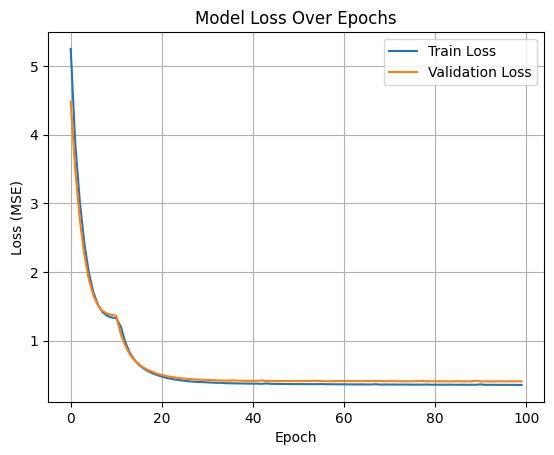

In [5]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# *Evluate the model*

In [6]:
# Returns MSE and MAE on the test set
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3701 - mae: 0.4247
Test Loss (MSE): 0.3706
Test MAE: 0.4279
